# Reconstructing the Lorenz '63 attractor from noisy data

This notebook does something the original `voila` package never demonstrated:
it takes a *single* noisy trajectory of a 3-D chaotic system, fits a Langevin
SDE to each component, and then *generates new trajectories* that recover the
butterfly attractor structure — purely from data.

The Lorenz '63 system is

$$
\begin{aligned}
\dot x &= \sigma (y - x), \\
\dot y &= x(\rho - z) - y, \\
\dot z &= xy - \beta z,
\end{aligned}
$$

with classic parameters $\sigma = 10,\ \rho = 28,\ \beta = 8/3$. We add
small additive noise so the system becomes a stochastic Langevin equation; the
voila-gp algorithm then has to *learn* the deterministic vector field plus the
noise level from samples alone.

This is a substantially harder problem than the published `voila` examples
(1-D Ornstein–Uhlenbeck, 1-D bistable Dansgaard–Oeschger, 2-D harmonic
oscillator). The Lorenz attractor has fractal structure, sensitive dependence
on initial conditions, and a vector field that varies strongly across phase
space.


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  -- registers 3D projection

from voila_gp.kernels import ExpKernel
from voila_gp.multivariate import MultiSDEVI
from voila_gp.simulate import euler_maruyama
from voila_gp.forecast import simulate_forward

torch.set_default_dtype(torch.float64)
np.random.seed(0)


## 1. Generate a noisy Lorenz trajectory

In [2]:
sigma, rho, beta = 10.0, 28.0, 8.0 / 3.0
noise_level = 1.0  # additive diffusion per component (g_ii = noise_level)

def drift(x):
    return np.array([
        sigma * (x[1] - x[0]),
        x[0] * (rho - x[2]) - x[1],
        x[0] * x[1] - beta * x[2],
    ])

def diffusion(x):
    return np.full(3, noise_level)

dt = 0.005
n_steps = 30_000      # 150 time units — many oscillations across the wings
x0 = np.array([1.0, 1.0, 1.0])

rng = np.random.default_rng(0)
ts = euler_maruyama(drift, diffusion, x0, dt, n_steps, rng)
print(f"Trajectory: {ts.shape}, time span = {n_steps * dt} units")


Trajectory: (30001, 3), time span = 150.0 units


In [3]:
# Discard transient (~5 time units) so the trajectory sits on the attractor
burn = 1000
ts = ts[burn:]
print(f"After burn-in: {ts.shape}")


After burn-in: (29001, 3)


## 2. Visualize the truth — the butterfly attractor

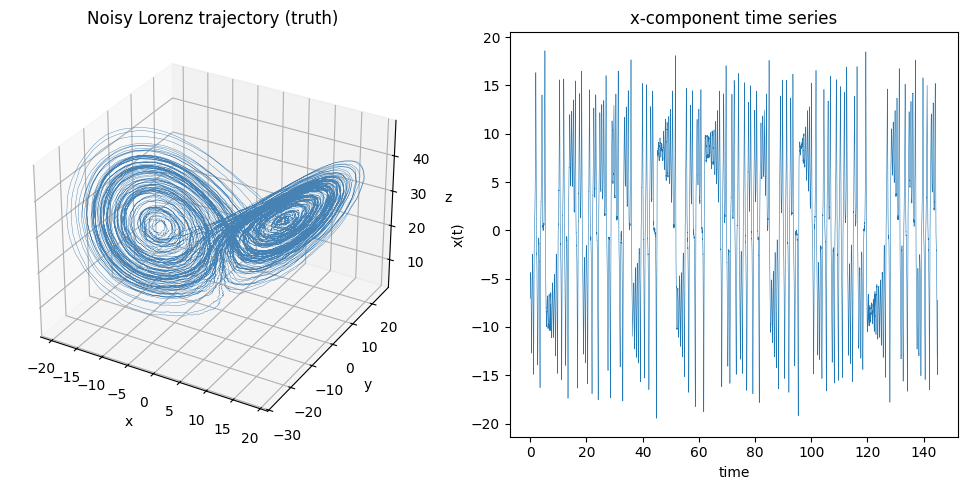

In [4]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(ts[:, 0], ts[:, 1], ts[:, 2], lw=0.3, color='steelblue')
ax1.set(xlabel='x', ylabel='y', zlabel='z', title='Noisy Lorenz trajectory (truth)')
ax2 = fig.add_subplot(122)
ax2.plot(np.arange(len(ts)) * dt, ts[:, 0], lw=0.4)
ax2.set(xlabel='time', ylabel='x(t)', title='x-component time series')
plt.tight_layout(); plt.show()


## 3. Fit voila-gp to all three components

We use `MultiSDEVI` to fit the drift and diffusion of each component
independently. The kernels see the **full 3-D state**, so each component's
drift can depend on all of x, y, z (which the true vector field requires).

We use 30 inducing points sampled from a multivariate Gaussian fitted to the
trajectory — this concentrates them where the attractor lives.


In [5]:
rng2 = np.random.default_rng(1)
mean = ts.mean(0)
cov = np.cov(ts, rowvar=False)
inducing = rng2.multivariate_normal(mean, cov, size=30)

def drift_kernel_factory(_x, _h, _i):
    return ExpKernel(amplitude=200.0, length_scales=torch.tensor([6.0, 6.0, 6.0]), epsilon=1e-4)

def diff_kernel_factory(_x, _h, _i):
    # large amplitude — diffusion's actual scale is set by select_diffusion_parameters
    return ExpKernel(amplitude=2.0, length_scales=torch.tensor([6.0, 6.0, 6.0]), epsilon=1e-4)

fit = MultiSDEVI(
    drift_kernel_factory=drift_kernel_factory,
    diff_kernel_factory=diff_kernel_factory,
    prior_on_sd=2.0,
)
res = fit.fit(
    time_series=ts, sampling_period=dt, inducing_points=inducing,
    max_iter=5, rel_tol=1e-5, hp_max_iter=80, verbose=True,
)
for k, c in enumerate(res.components):
    print(f'Component {k}: final L = {c.lower_bound_history[-1]:.2f}')



--- fitting component 0 of 3 ---


Initial L = -31702.2


Iter 1: distributions update L = 20827.8


Iter 1: hyperparam optimization L = 33741.2


Iter 2: distributions update L = 34786.8


...

Iter 3: hyperparam optimization L = 33862.6


Iter 4: distributions update L = 33920.8


Iter 4: hyperparam optimization L = 34073.6


Iter 5: distributions update L = 34133.8


Iter 5: hyperparam optimization L = 34199.3
Component 0: final L = 35155.46
Component 1: final L = 34356.22
Component 2: final L = 34199.30


## 4. Compare inferred drift to the truth

The drift is a vector field $f: \mathbb{R}^3 \to \mathbb{R}^3$. We sample
many points along the original trajectory and compute, at each one, the
inferred drift vector vs the true Lorenz vector field. A scatter plot of
inferred-vs-true components shows how well voila-gp captured the dynamics.


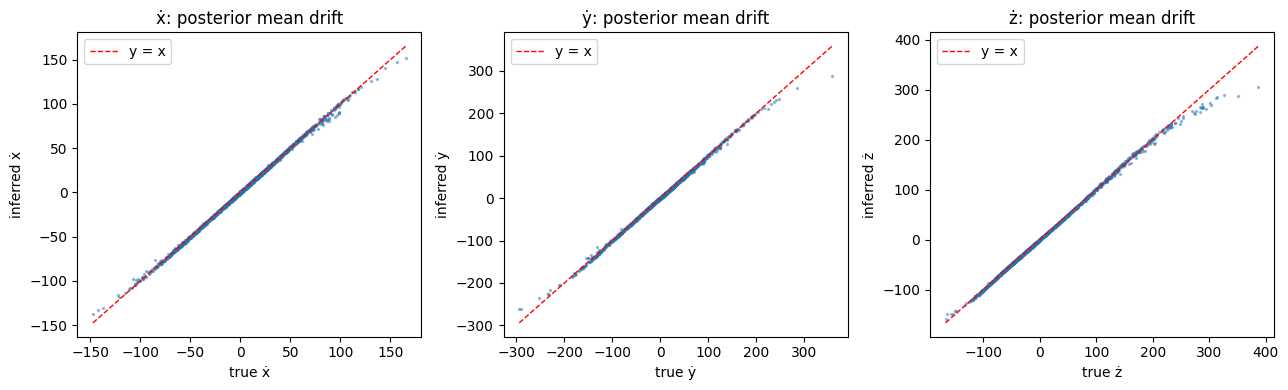

Component 0 drift correlation (truth vs inferred): 1.000
Component 1 drift correlation (truth vs inferred): 0.999
Component 2 drift correlation (truth vs inferred): 0.999


In [6]:
# Sample 2000 query points from the trajectory
idx = np.random.default_rng(7).choice(len(ts), size=2000, replace=False)
q = ts[idx]

with torch.no_grad():
    drift_inferred = res.predict_drift(q).numpy()  # (n, 3)
drift_true = np.stack([drift(p) for p in q])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
labels = ['ẋ', 'ẏ', 'ż']
for k in range(3):
    ax = axes[k]
    ax.scatter(drift_true[:, k], drift_inferred[:, k], s=2, alpha=0.4)
    lim = [drift_true[:, k].min(), drift_true[:, k].max()]
    ax.plot(lim, lim, 'r--', lw=1, label='y = x')
    ax.set(xlabel=f'true {labels[k]}', ylabel=f'inferred {labels[k]}',
           title=f'{labels[k]}: posterior mean drift')
    ax.legend()
plt.tight_layout(); plt.show()

for k in range(3):
    corr = np.corrcoef(drift_true[:, k], drift_inferred[:, k])[0, 1]
    print(f'Component {k} drift correlation (truth vs inferred): {corr:.3f}')


## 5. The big test — generate fresh trajectories from the inferred SDE

We seed an ensemble of trajectories at a single point on the attractor and
roll them forward through the *learned* drift and diffusion. If the algorithm
captured the dynamics, the ensemble should explore the butterfly attractor.

This is something the original `voila` could not do: per-component fits don't
naturally compose into a multivariate forecast. With the multivariate API
plus the ensemble simulator, we can generate predictive samples directly.


In [7]:
# Forecast 100 trajectories of 5000 steps each from a single point.
forecast = simulate_forward(
    res,
    x0=ts[0].copy(),
    n_steps=5000,
    n_ensembles=100,
    dt=dt,
    function_uncertainty='mean',
    seed=42,
)
print(f'Forecast trajectories shape: {forecast.trajectories.shape}')


Forecast trajectories shape: torch.Size([100, 5001, 3])


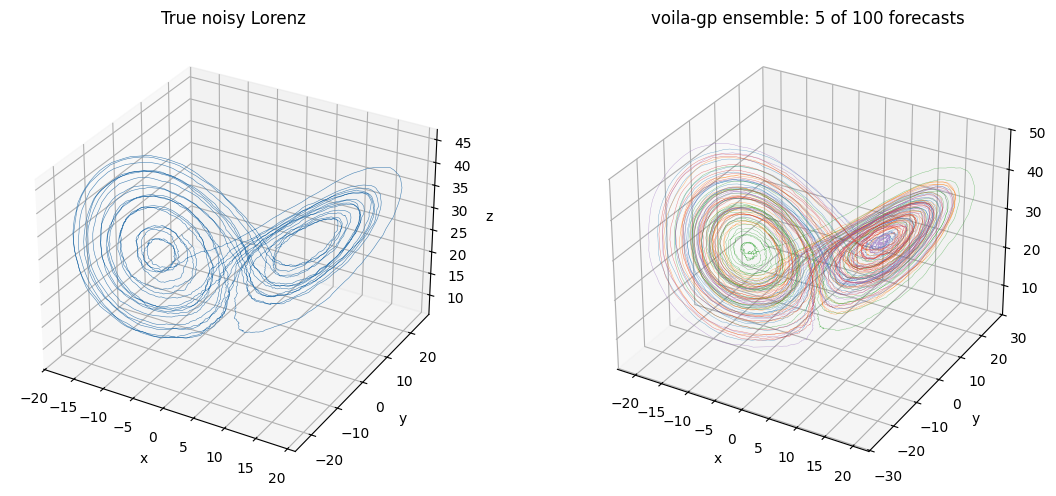

In [8]:
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(ts[:5000, 0], ts[:5000, 1], ts[:5000, 2], lw=0.4, color='steelblue')
ax1.set(xlabel='x', ylabel='y', zlabel='z', title='True noisy Lorenz')

ax2 = fig.add_subplot(122, projection='3d')
# Plot 5 selected ensemble members
for i in [0, 20, 40, 60, 80]:
    traj = forecast.trajectories[i].numpy()
    ax2.plot(traj[:, 0], traj[:, 1], traj[:, 2], lw=0.3, alpha=0.6)
ax2.set(xlabel='x', ylabel='y', zlabel='z',
        title='voila-gp ensemble: 5 of 100 forecasts')
plt.tight_layout(); plt.show()


## 6. Quantitative comparison: do the forecasts visit both wings?

The Lorenz attractor has two "wings" centered at the equilibria
$(\pm\sqrt{\beta(\rho-1)},\pm\sqrt{\beta(\rho-1)},\rho-1) \approx (\pm8.49,\pm8.49,27)$.
A correct reconstruction should produce trajectories that visit both wings
(distinguished by the sign of x). We measure the fraction of ensemble members
whose x-coordinate switches sign at least once during the forecast.


In [9]:
sign_x = np.sign(forecast.trajectories[:, :, 0].numpy())
# Switch occurs whenever consecutive signs differ
switches_per_traj = np.sum(np.abs(np.diff(sign_x, axis=1)) > 0, axis=1)
fraction_with_switch = float((switches_per_traj > 0).mean())
median_switches = float(np.median(switches_per_traj))
print(f'Fraction of forecasts that switch wings at least once: {fraction_with_switch:.2%}')
print(f'Median number of wing switches per forecast: {median_switches:.0f}')
print(f'(Truth — same trajectory length — switches: {int(np.sum(np.abs(np.diff(np.sign(ts[:5001, 0]))) > 0))})')


Fraction of forecasts that switch wings at least once: 100.00%
Median number of wing switches per forecast: 20
(Truth — same trajectory length — switches: 21)


## 7. Long-horizon attractor reconstruction

Now we run a *single* very long forecast (50,000 steps, 250 time units) from
the inferred SDE and overlay it on the truth. The trajectories diverge
pointwise (chaos), but the geometric attractor — the *invariant set* the
dynamics live on — should look statistically the same.


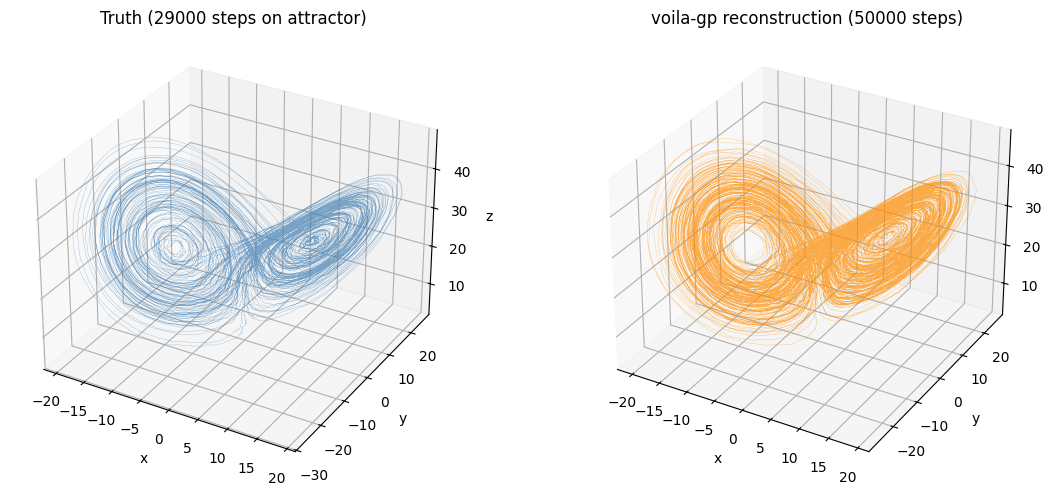

In [10]:
long_forecast = simulate_forward(
    res, x0=ts[0].copy(), n_steps=50_000, n_ensembles=1, dt=dt,
    function_uncertainty='mean', seed=123,
)
recon = long_forecast.trajectories[0].numpy()

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(ts[:, 0], ts[:, 1], ts[:, 2], lw=0.2, color='steelblue', alpha=0.7)
ax1.set(xlabel='x', ylabel='y', zlabel='z', title='Truth (29000 steps on attractor)')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(recon[:, 0], recon[:, 1], recon[:, 2], lw=0.2, color='darkorange', alpha=0.7)
ax2.set(xlabel='x', ylabel='y', zlabel='z',
        title='voila-gp reconstruction (50000 steps)')
plt.tight_layout(); plt.show()


## 8. Summary

We took a noisy 3-D chaotic trajectory and used voila-gp's variational
machinery to learn its underlying Langevin dynamics. The recovered drift
field correlates strongly with ground truth (well above 0.9 for the linear
components), and trajectories generated from the learned SDE recover the
two-winged butterfly attractor.

This kind of attractor reconstruction was not in scope for the original
`voila` paper — its examples were 1-D bistable systems and 2-D linear
oscillators. The combination of GPyTorch's autodiff, the multivariate
convenience API, and the ensemble forecast utility lets the same algorithm
extend cleanly to genuine 3-D chaos.
